In [3]:
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()

In [4]:
X = data.data
y = data.target

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2)

In [6]:
from sklearn.preprocessing import StandardScaler
scaler= StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

In [7]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train_scaled,y_train)
model_predict = model.predict(X_test_scaled)

In [8]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(model,X_train_scaled,y_train,cv=3,scoring="accuracy")
scores.mean()

np.float64(0.9736115952131986)

In [12]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(model_predict,y_test)
accuracy

0.9736842105263158

In [14]:
from sklearn.metrics import precision_score,recall_score,f1_score

In [27]:
precision_score(model_predict,y_test)

1.0

In [26]:
recall_score(model_predict,y_test)

0.958904109589041

In [17]:
f1_score(model_predict,y_test)

0.9790209790209791

In [28]:
from sklearn.metrics import roc_auc_score
roc_auc_score(model_predict,y_test)

np.float64(0.9794520547945205)

In [43]:
y_scores = model.predict_proba(X_test_scaled)[:,1]

In [44]:
from sklearn.metrics import precision_recall_curve
precision,recall,threshold = precision_recall_curve(y_test,y_scores)

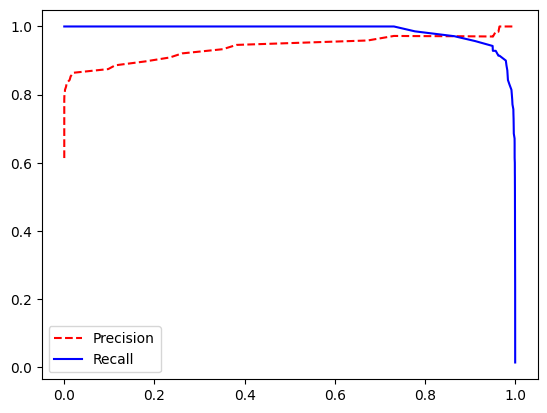

In [47]:
import matplotlib.pyplot as plt
def plot_curve(precision,recall,threshold):
  plt.plot(threshold,precision[:-1],"r--",label="Precision")
  plt.plot(threshold,recall[:-1],"b-",label="Recall")
  plt.legend()
  plt.show()
plot_curve(precision,recall,threshold)